## 1. a  What is the difference between classification and clustering?

The key difference between classification and clustering lies in the type of learning and the presence of labeled data. Classification is a type of supervised learning, where the model is trained on input data that comes with predefined labels. The goal of classification is to learn a mapping from inputs to specific categories or classes—for example, determining whether an email is spam or not based on past labeled examples. In contrast, clustering is an unsupervised learning technique, which means it deals with data that has no predefined labels. The objective of clustering is to group similar data points together based on patterns or similarities in the features. A common example is customer segmentation, where the algorithm groups customers based on purchasing behavior without knowing any prior labels. So, while classification requires known outcomes to learn from, clustering seeks to discover hidden structures in unlabeled data.










## b Can we use evaluation metrics such as accuracy, precision, and recall for clustering?

Not directly, unless we have ground truth labels (which is rare in clustering). Here's why:

Accuracy, precision, and recall depend on class labels.

In clustering, labels are often unknown or arbitrary (e.g., Cluster 0 could represent anything).

You can use these metrics if you’re benchmarking against known classes (like in synthetic datasets or validation experiments).

## c Which evaluation method is used for clustering when there is no output label?

The most common evaluation method is:

Silhouette Score
Definition: Measures how similar a data point is to its own cluster (cohesion) compared to other clusters (separation).

 The value ranges from -1 to 1, though higher values indicate better-defined clusters.

Formula for a single point: Silhouette = b - a / Max(a,b),,
Where:
a = average distance to points in the same cluster
b = average distance to points in the nearest other cluster

## d  How do we choose the number of clusters in the K-means model when there is no output label?

A common method is the:

Elbow Method::
Run K-means for a range of k values (e.g., 1–10).
Plot the inertia (sum of squared distances from points to cluster centers) against k.
Look for the "elbow" point where the rate of decrease sharply slows — that's a good k.



## e How do we choose a reasonable value for epsilon (ε) in DBSCAN clustering?

The best way is through the:

k-distance Graph Method,.
For each data point, compute the distance to its k-th nearest neighbor (usually k = minPts).
Sort these distances and plot them.
The "elbow" point in the plot is a good choice for epsilon (ε).

Tips:

Too small (ε) → many small/noise clusters.
Too large (ε) → all points may fall into one cluster.

## Problem 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from collections import Counter

In [4]:
# Load data
df = pd.read_csv('HW10_InvestorData.csv')  # Assuming you're using the investor dataset here
df.sample(5)

,ID,AGE,EDUC,MARRIED,KIDS,LIFECL,OCCAT,RISK,HHOUSES,WSAVED,SPENDMOR,NWCAT,INCCL
3427,3428,3,3,1,2,3,1,2,1,3,4,5,5
1557,1558,1,2,1,1,3,1,2,1,3,2,4,4
1610,1611,5,2,1,0,5,1,3,1,3,5,3,4
3490,3491,1,3,2,0,1,4,4,0,2,4,1,2
1141,1142,4,1,1,0,5,1,4,1,2,2,2,1


In [6]:
df.describe()

,ID,AGE,EDUC,MARRIED,KIDS,LIFECL,OCCAT,RISK,HHOUSES,WSAVED,SPENDMOR,NWCAT,INCCL
count,3866.000000,3866.000000,3866.000000,3866.000000,3866.000000,3866.000000,3866.000000,3866.000000,3866.000000,3866.000000,3866.000000,3866.000000,3866.000000
mean,1933.500000,3.107346,2.906363,1.353337,0.937662,3.696844,1.741593,3.042938,0.716503,2.445939,3.561045,2.976203,3.671495
std,1116.162399,1.512556,1.066253,0.478068,1.249059,1.617554,0.934443,0.879385,0.450754,0.743267,1.304197,1.462937,1.183631
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,967.250000,2.000000,2.000000,1.000000,0.000000,3.000000,1.000000,2.000000,0.000000,2.000000,2.000000,2.000000,3.000000
50%,1933.500000,3.000000,3.000000,1.000000,0.000000,3.000000,1.000000,3.000000,1.000000,3.000000,4.000000,3.000000,4.000000
75%,2899.750000,4.000000,4.000000,2.000000,2.000000,5.000000,3.000000,4.000000,1.000000,3.000000,5.000000,4.000000,5.000000
max,3866.000000,6.000000,4.000000,2.000000,8.000000,6.000000,4.000000,4.000000,1.000000,3.000000,5.000000,5.000000,5.000000


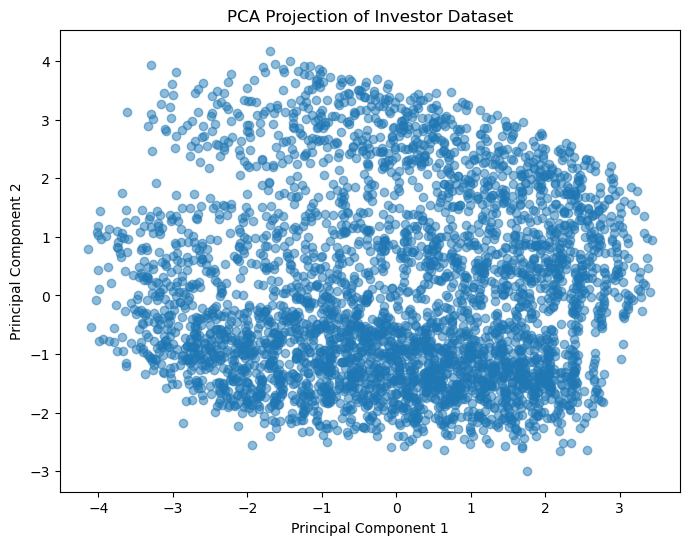

In [7]:
# Standardize features
x = StandardScaler().fit_transform(df)

# -----------------------------
# a. PCA Visualization
# -----------------------------
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

plt.figure(figsize=(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], alpha=0.5)
plt.title("PCA Projection of Investor Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## 
What We See in the Graph:
The data points form a dense, continuous cloud, roughly elliptical, with no clear, well-separated clusters.
There appears to be varying density, especially a denser central area with sparser outer edges.
K-Means:
Assumes spherical, equally-sized, and equally dense clusters.
Works best when the data is clearly separable into distinct, well-defined groups.
Likely not ideal here because:
No obvious cluster centroids.
Density varies.
DBSCAN (Density-Based Spatial Clustering of Applications with Noise):
Detects clusters of arbitrary shapes and varies in density.
Can identify outliers (noise).
Well-suited for this case because:(DBSCAN)
The data has a continuous spread with density variation.
It’s possible that natural clusters are defined by local density, not center-based distance.
Most Suitable: DBSCAN
This method is better equipped to handle the density-based clustering suggested by the PCA plot of your investor dataset.

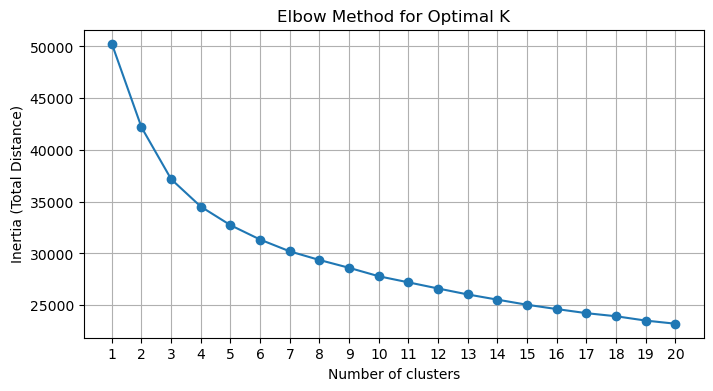

In [11]:
# -------------------------------------
# b. Elbow method for KMeans Clustering
# -------------------------------------
n_clusters = np.arange(1, 21)
inertias = []

for k in n_clusters:
    km = KMeans(n_clusters=k, n_init=25, random_state=101)
    km.fit(x)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(n_clusters, inertias, marker='o')
plt.xticks(n_clusters)
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia (Total Distance)")
plt.grid(True)
plt.show()

In [14]:
# Apply KMeans with optimal K 
k_opt = 4
km = KMeans(n_clusters=k_opt, n_init=25, random_state=101)
km.fit(x)
y_kmeans = km.labels_
df['kmeans_cluster'] = y_kmeans

# Count investors per cluster
print("KMeans Cluster Counts:", Counter(y_kmeans))

KMeans Cluster Counts: Counter({3: 1388, 1: 999, 2: 835, 0: 644})


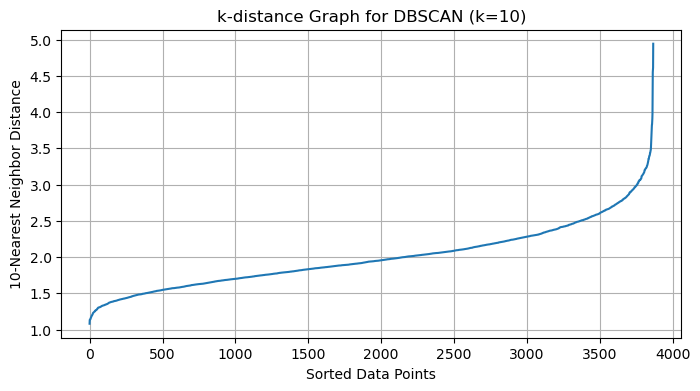

In [15]:
# -------------------------------------
# c. DBSCAN Clustering
# -------------------------------------
# Optional: k-distance plot (to pick eps)
from sklearn.neighbors import NearestNeighbors

k = 10
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(x)
distances, indices = neighbors_fit.kneighbors(x)

# Sort distances for the k-th nearest neighbor
k_distances = np.sort(distances[:, k-1])
plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title("k-distance Graph for DBSCAN (k=10)")
plt.ylabel(f"{k}-Nearest Neighbor Distance")
plt.xlabel("Sorted Data Points")
plt.grid(True)
plt.show()

In [16]:
# Apply DBSCAN
db = DBSCAN(eps=1.5, min_samples=10)  # Adjust `eps` based on the graph above
db.fit(x)
db_labels = db.labels_
df['dbscan_cluster'] = db_labels

# Count investors per cluster
print("DBSCAN Cluster Counts:", Counter(db_labels))

DBSCAN Cluster Counts: Counter({-1: 2857, 0: 790, 1: 52, 4: 52, 3: 35, 5: 24, 6: 15, 8: 13, 7: 11, 2: 10, 9: 7})


In [17]:
# Silhouette score for KMeans
ss_kmeans = silhouette_score(x, y_kmeans)
print(f"KMeans Silhouette Score = {ss_kmeans:.3f}")

# Silhouette score for DBSCAN (excluding noise)
mask = db_labels != -1
if np.sum(mask) > 1:
    ss_dbscan = silhouette_score(x[mask], db_labels[mask])
    print(f"DBSCAN Silhouette Score = {ss_dbscan:.3f}")
else:
    print("Too few points to compute DBSCAN silhouette score.")

KMeans Silhouette Score = 0.128
DBSCAN Silhouette Score = 0.060


## KMeans model performs a better clustering.

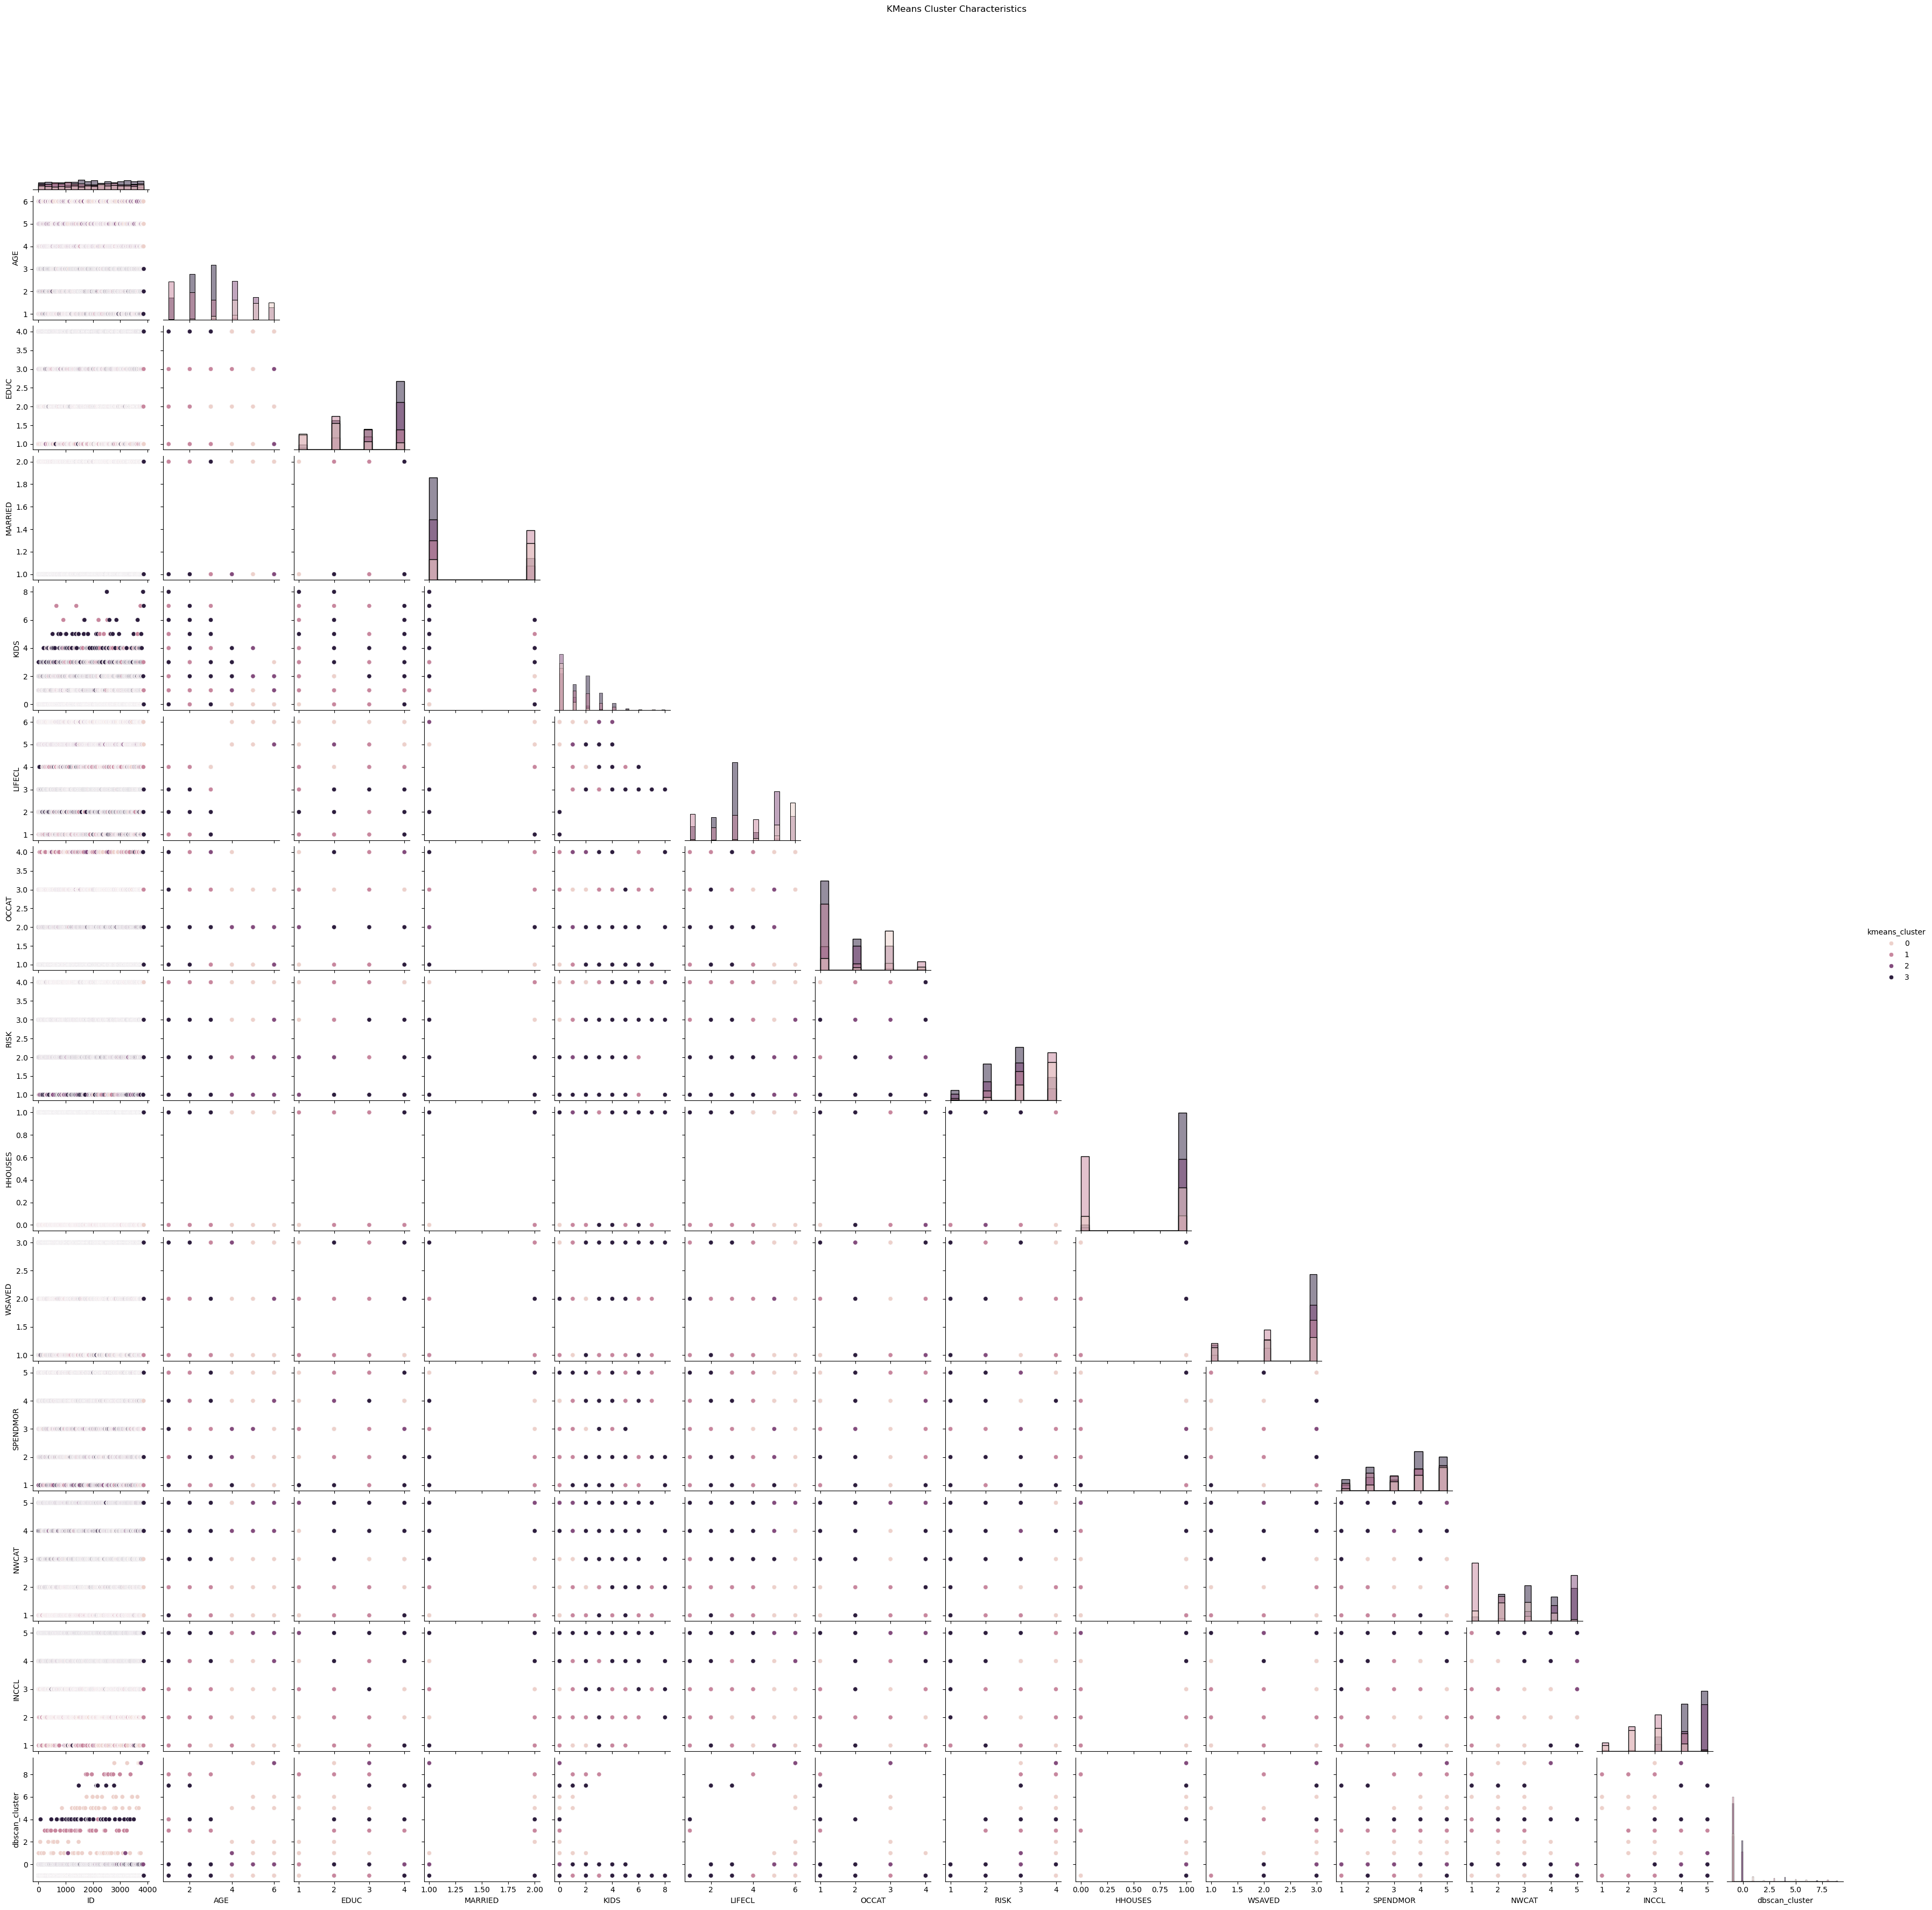

In [19]:
# -------------------------------------
# e. Visualize cluster features
# ------------------------------------
sns.pairplot(df, hue='kmeans_cluster', diag_kind='hist', corner=True)
plt.suptitle("KMeans Cluster Characteristics", y=1.02)
plt.show()